In [1]:
#Importing relevent packages
import sys; print(sys.executable)
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta

#Importing kernels file
import custom_kernels as ck

#SETTINGS
#Time-related settings
starttime = datetime(2024,7,1)
endtime = datetime(2024,8,1)
dtime_data = timedelta(days=1)    #je stelt hier handmatig in wat de tijdsresolutie is van je data #deze kan niet naar minuten (13/5/2025)
dtime_execute = timedelta(minutes=10)
simulation_days = 15    

#Selecting physical variables to add
add_stokes = True
avg_stokes = True
add_wind = True
add_T_N_calc = True

#Output storing
output_folder = "/storage/shared/oceanparcels/output_data/data_Elena/"
output_file_name = "SIM_june9_withoutN.zarr"

/nethome/6903894/parcels_env/bin/python


In [2]:


##################################################################################################
#Loading the physical dataset and matching the grid
directory_phy =  '/storage/shared/oceanparcels/input_data/MOi/'
phy_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc' 
phy_files_U = []
phy_files_V = []
phy_files_T = []

time = starttime
phy_file_W = directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc'.format(vector = 'W', y = time.year, m = time.month, d = time.day)
while(time < endtime):
    phy_files_U.append(phy_base_file.format(vector = 'U', y = time.year, m = time.month, d = time.day))
    phy_files_V.append(phy_base_file.format(vector = 'V', y = time.year, m = time.month, d = time.day))
    phy_files_T.append(phy_base_file.format(vector = 'T', y = time.year, m = time.month, d = time.day))
    time+=dtime_data

#print(phy_files_U)

mesh_file_h = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_hgr.nc"   #Hiermee converteren we het grid!
mesh_file_z = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_zgr.nc"
filenames_phy = {'U': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_U,
    }, 'V': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_V,
    }, 'T': {'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_T,
    }
}
variables_phy = {'U': 'vozocrtx',
                'V': 'vomecrty',
                'T': 'votemper'}

c_grid_dimensions = {   'lat': 'gphif',
                        'lon': 'glamf',
                        'depth':'depthw',
                        'time': 'time_counter'}

dimensions_phy = {'U': c_grid_dimensions,
                 'V': c_grid_dimensions,
                 'T': c_grid_dimensions}

#Defining a range of indices to load as fieldset to reduce computational time
indices = {'lat': range(800,1800),
           'lon': range(2100,3500)
           }

#Creating fieldset
fieldset = parcels.FieldSet.from_nemo(filenames=filenames_phy,variables=variables_phy,dimensions=dimensions_phy, indices=indices)
print('fieldset = made')

#Adding the wave/stokes data
if avg_stokes:
    sarg_depth_extent = 1  

if add_stokes:
    directory_stokes = '/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/'
    stokes_base_file =  directory_stokes + 'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_{y:04d}-{m:02d}-{d:02d}-{y:04d}-{m:02d}-{d:02d}.nc' 
    
    stokes_files = []

    time = starttime
    while(time < endtime):
        stokes_files.append(stokes_base_file.format(y = time.year, m = time.month, d = time.day ))
        time+=dtime_data

    #print(stokes_files)
    
    filenames_stokes = {'U_wave_Stokes': stokes_files,
                    'V_wave_Stokes': stokes_files,
                    'wave_Tp': stokes_files,
                    }
    variables_stokes = {'U_wave_Stokes': 'VSDX',        #Sea surface wave stokes drift x velocity
                    'V_wave_Stokes': 'VSDY',            #Sea surface wave stokes drift y velocity
                    'wave_Tp': 'VTPK'                   #Wave peak period
                    }
    dimensions_stokes = {'lat': 'latitude',
                        'lon': 'longitude',
                        'time': 'time'}
    
    #Defining a range of indices to load as fieldset to reduce computational time
    indices_stokes = {'lat': range(650,1750),
                       'lon': range(800,2500)
                     } 
    
    fieldset_stokes = parcels.FieldSet.from_netcdf(filenames=filenames_stokes, variables=variables_stokes, dimensions=dimensions_stokes, indices=indices_stokes)

    #Converting units
    fieldset_stokes.U_wave_Stokes.units = parcels.tools.converters.GeographicPolar()
    fieldset_stokes.V_wave_Stokes.units = parcels.tools.converters.Geographic()

    #Adding fields to initial fields
    fieldset.add_field(fieldset_stokes.U_wave_Stokes)
    fieldset.add_field(fieldset_stokes.V_wave_Stokes)

    #Only required if more advanced Stokes drift is implemented
    if avg_stokes:
        fieldset.add_field(fieldset_stokes.wave_Tp)
        fieldset.add_constant('G', 9.81)  # Gravitational constant [m s-1]
        fieldset.add_constant('depth_extent', sarg_depth_extent)  # depth extent of the sargassum [in m]

if add_wind:

    ds = xr.open_mfdataset('/storage/shared/oceanparcels/input_data/ERA5/reanalysis-era5-single-level_wind10m_2024*.nc')

    filenames_wind = ds.sel(valid_time=slice(starttime, endtime))

    variables_wind = {'U_wind': 'u10', 
                      'V_wind':'v10'}

    dimensions_wind = {'lon':'longitude', 
                       'lat': 'latitude', 
                       'time': 'valid_time'}

    fieldset_wind= parcels.FieldSet.from_xarray_dataset(filenames_wind, variables_wind, dimensions_wind, mesh='spherical')

    fieldset_wind.add_periodic_halo(zonal=True)

    windage_factor = 0.01

    fieldset_wind.U_wind.set_scaling_factor(windage_factor)
    fieldset_wind.V_wind.set_scaling_factor(windage_factor)

    fieldset_wind.U_wind.units = parcels.tools.converters.GeographicPolar()
    fieldset_wind.V_wind.units = parcels.tools.converters.Geographic()

    fieldset.add_field(fieldset_wind.U_wind)
    fieldset.add_field(fieldset_wind.V_wind)

if add_T_N_calc:
    #Overall average growth rate (Corbin & Oxenford)
    fieldset.add_constant('RGR_SF3', 0.077) 
    fieldset.add_constant('RGR_SN1', 0.046)
    fieldset.add_constant('RGR_SN8', 0.032)
    #Overall maximal growth rate (Corbin & Oxenford)
    fieldset.add_constant('MGR_SF3', 0.124) 
    fieldset.add_constant('MGR_SN1', 0.083)
    fieldset.add_constant('MGR_SN8', 0.053)
    #Set initial weight
    fieldset.add_constant('initial_weight', 50) #grams

    nitrogen_file_path = '/nethome/6903894/testing/Input_data_test/'
    nitrogen_file = 'cmems_mod_glo_bgc-nut_anfc_0.25deg_P1D-m_1748337531153.nc'
    ds_N = xr.open_dataset(nitrogen_file_path + nitrogen_file)

    filename_N = ds_N.sel(time=slice(starttime, endtime))

    variables_N = {'no3': 'no3'}

    dimensions_N = {'lon':'longitude', 
                       'lat': 'latitude',
                       'depth' : 'depth',
                       'time': 'time'}

    fieldset_nitrogen = parcels.FieldSet.from_xarray_dataset(filename_N, variables=variables_N, dimensions=dimensions_N)

    #Converting units
    #fieldset_stokes.U_wave_Stokes.units = parcels.tools.converters.GeographicPolar()
    #fieldset_stokes.V_wave_Stokes.units = parcels.tools.converters.Geographic()

    #Adding fields to initial fields
    fieldset.add_field(fieldset_nitrogen.no3)

fieldset = made


/nethome/6903894/parcels_env/lib/python3.13/site-packages/parcels/grid.py:563: FieldSetWarning: Flipping lat data from North-South to South-North. Note that this may lead to wrong sign for meridional velocity, so tread very carefully
  super().__init__(lon, lat, time, time_origin, mesh)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/parcels/grid.py:563: FieldSetWarning: Flipping lat data from North-South to South-North. Note that this may lead to wrong sign for meridional velocity, so tread very carefully
  super().__init__(lon, lat, time, time_origin, mesh)


In [115]:
print(len(fieldset.T.lon))
print(len(fieldset.T.lat))
print(np.shape(fieldset.T.data))

1000
1000
()


/tmp/ipykernel_4089/2818776232.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  pplot = ax.plot(pset.lon, pset.lat, "ko", color='darkblue')


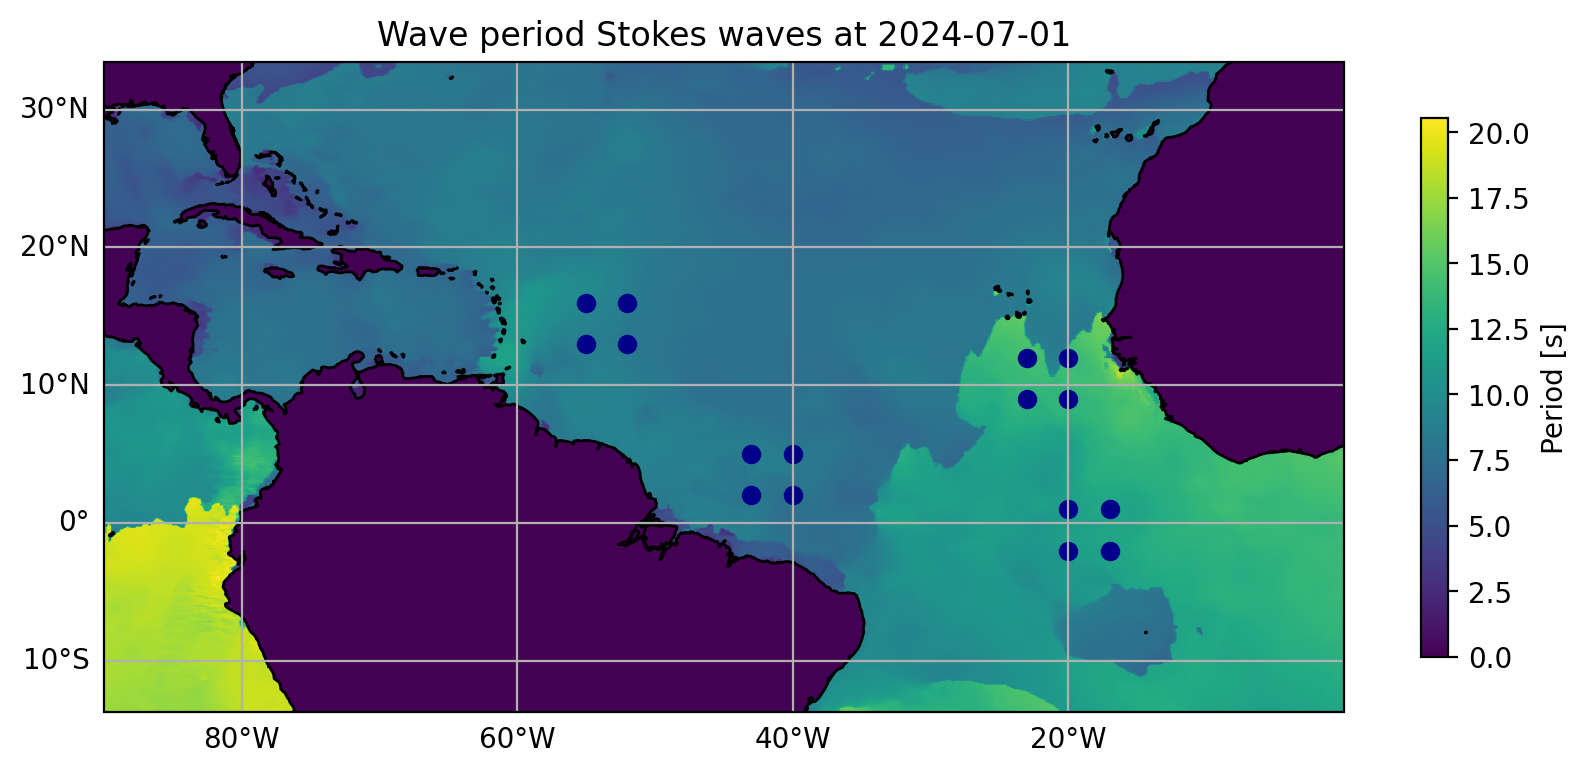

In [5]:
#By using fieldset.computeTimeChunk(), we load the first time frame of the fieldset.
fieldset.computeTimeChunk()

#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7), dpi = 200)
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.U_wave_Stokes.lon, fieldset.U_wave_Stokes.lat, fieldset.wave_Tp.data[0,:,:], 
                transform=ccrs.PlateCarree())
pplot = ax.plot(pset.lon, pset.lat, "ko", color='darkblue')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Wave period Stokes waves at {starttime.date()}')
ax.set_extent([-90,0,-10,25])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5, anchor=(0.0, 0.5))
cbar.set_label('Period [s]')
plt.show()

In [30]:
print(fieldset.U.depth[0:10])

[ 0.         1.0112752  2.085676   3.2230012  4.4371614  5.7451367
  7.1676517  8.729996  10.463024  12.404372 ]


(2, 50, 1000, 1400)
[ 0.         1.0112752  2.085676   3.2230012  4.4371614  5.7451367
  7.1676517  8.729996  10.463024  12.404372 ]


<function matplotlib.pyplot.show(close=None, block=None)>

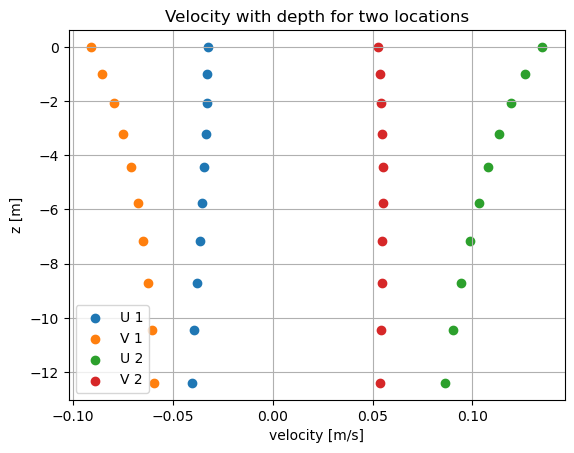

In [ ]:
print(np.shape(fieldset.U.data))
U_z = fieldset.U.data[0,:,400,1200]
V_z = fieldset.V.data[0,:,400,1200]
U_z2 = fieldset.U.data[0,:,300,1100]
V_z2 = fieldset.V.data[0,:,300,1100]

print(fieldset.U.depth[0:10])

plt.scatter( U_z[0:10],-fieldset.U.depth[0:10] , label='U 1')
plt.scatter( V_z[0:10],-fieldset.V.depth[0:10] , label='V 1')
plt.scatter( U_z2[0:10],-fieldset.U.depth[0:10] , label='U 2')
plt.scatter( V_z2[0:10],-fieldset.V.depth[0:10] , label='V 2')
plt.title('Velocity with depth for two locations')
plt.grid()
plt.legend()
plt.xlabel('velocity [m/s]')
plt.ylabel('z [m]')
plt.show

(32, 3, 241, 461)
[0.49402538 1.5413754  2.6456685 ]
[-100.    -99.75  -99.5   -99.25  -99.    -98.75  -98.5   -98.25  -98.
  -97.75  -97.5   -97.25  -97.    -96.75  -96.5   -96.25  -96.    -95.75
  -95.5   -95.25  -95.    -94.75  -94.5   -94.25  -94.    -93.75  -93.5
  -93.25  -93.    -92.75  -92.5   -92.25  -92.    -91.75  -91.5   -91.25
  -91.    -90.75  -90.5   -90.25  -90.    -89.75  -89.5   -89.25  -89.
  -88.75  -88.5   -88.25  -88.    -87.75  -87.5   -87.25  -87.    -86.75
  -86.5   -86.25  -86.    -85.75  -85.5   -85.25  -85.    -84.75  -84.5
  -84.25  -84.    -83.75  -83.5   -83.25  -83.    -82.75  -82.5   -82.25
  -82.    -81.75  -81.5   -81.25  -81.    -80.75  -80.5   -80.25  -80.
  -79.75  -79.5   -79.25  -79.    -78.75  -78.5   -78.25  -78.    -77.75
  -77.5   -77.25  -77.    -76.75  -76.5   -76.25  -76.    -75.75  -75.5
  -75.25  -75.    -74.75  -74.5   -74.25  -74.    -73.75  -73.5   -73.25
  -73.    -72.75  -72.5   -72.25  -72.    -71.75  -71.5   -71.25  -71.
  -70.75 

/tmp/ipykernel_494822/2300740719.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')


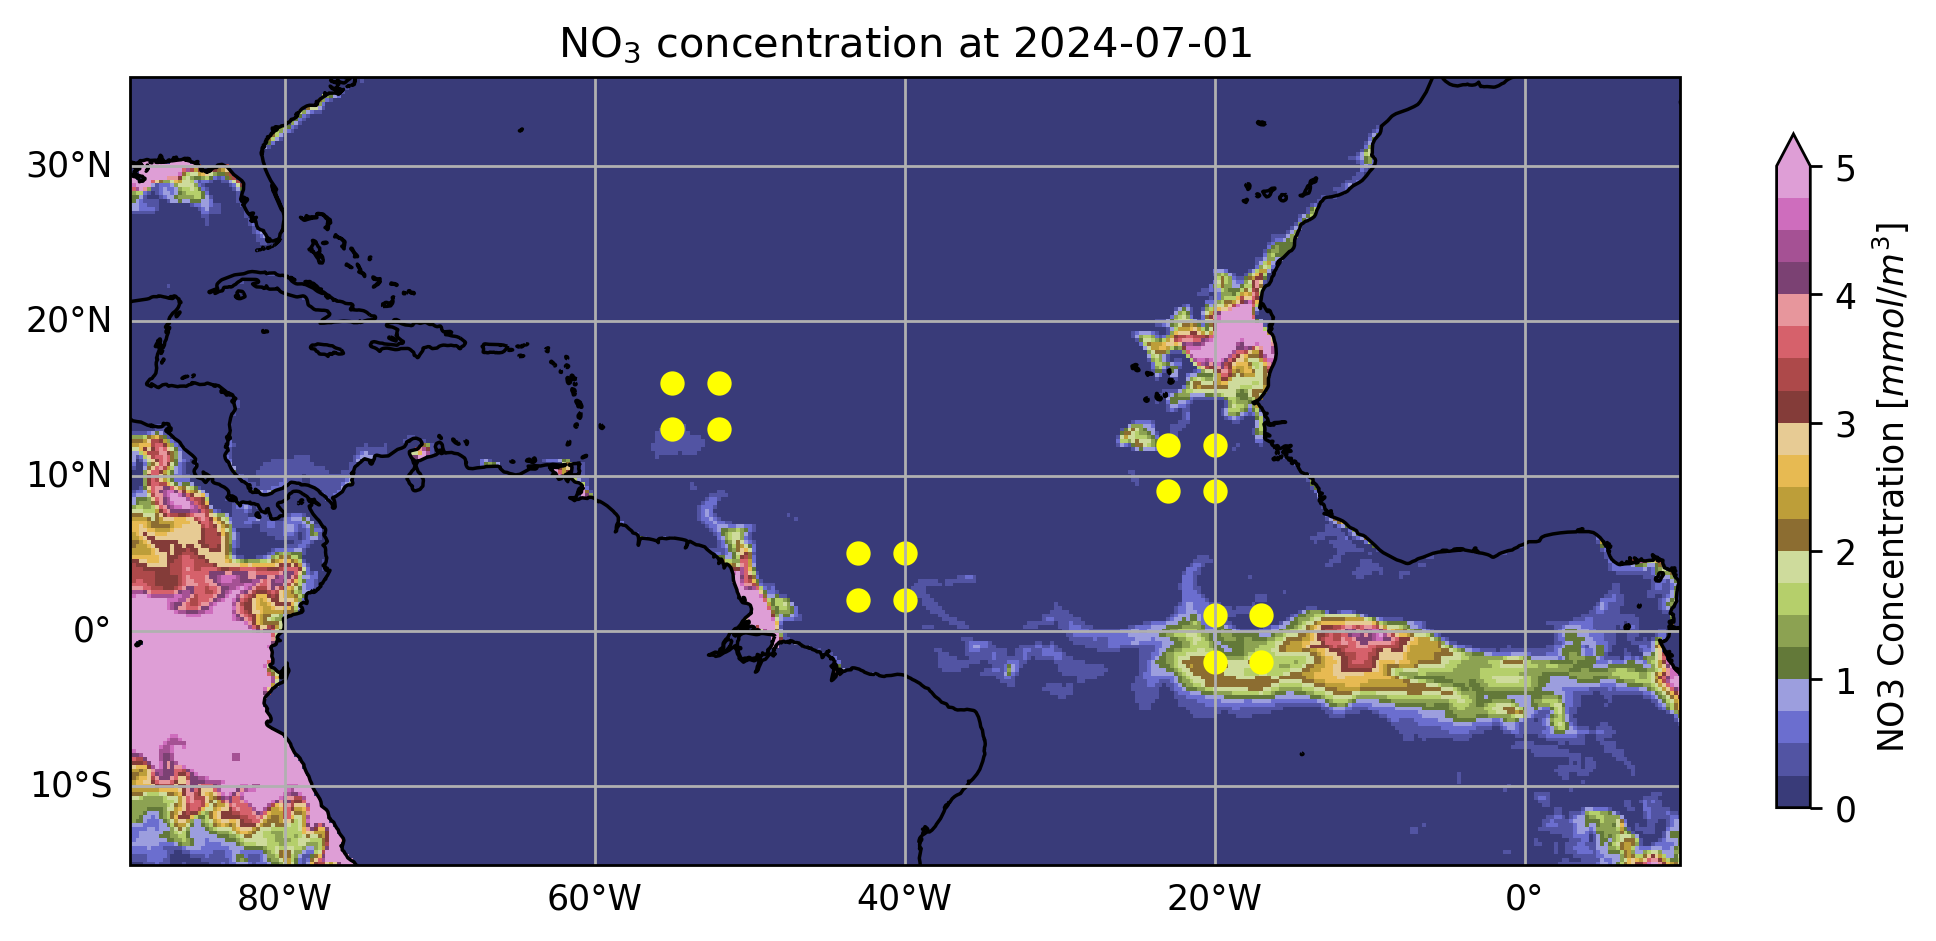

In [12]:
#By using fieldset.computeTimeChunk(), we load the first time frame of the fieldset.
fieldset.computeTimeChunk()

print(np.shape(fieldset.no3.data))

print(fieldset.no3.depth)
#print(fieldset.T.depth)
print(fieldset.no3.lon)

#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.no3.lon, fieldset.no3.lat, fieldset.no3.data[0,0,:,:], vmax = 5, cmap='tab20b',
             transform=ccrs.PlateCarree())
pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'NO$_3$ concentration at {starttime.date()}')
ax.set_extent([-90,10,-10,25])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5, extend = 'max')
cbar.set_label(f'NO3 Concentration [$mmol/m^3$]')
plt.show()

/tmp/ipykernel_494822/270063746.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')


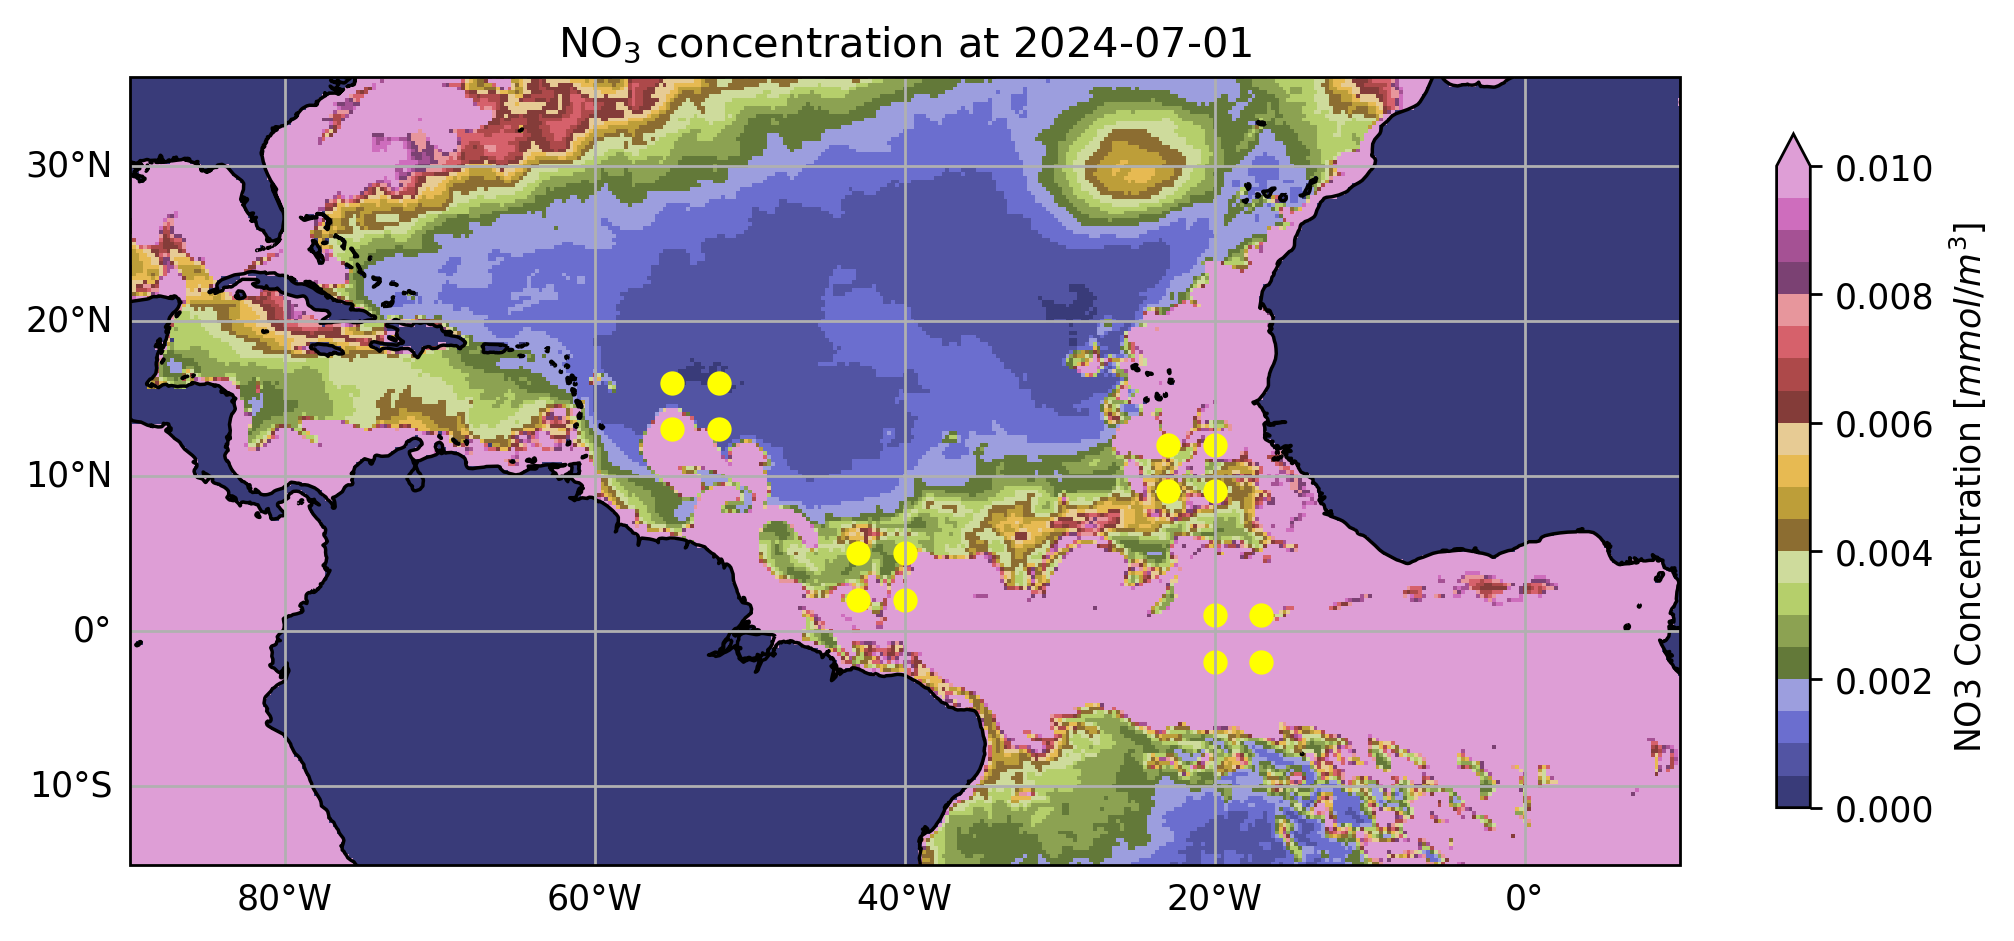

In [14]:
#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.no3.lon, fieldset.no3.lat, fieldset.no3.data[0,0,:,:], vmax = 0.01, cmap='tab20b',
             transform=ccrs.PlateCarree())
pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'NO$_3$ concentration at {starttime.date()}')
ax.set_extent([-90,10,-10,25])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5, extend = 'max')
cbar.set_label(f'NO3 Concentration [$mmol/m^3$]')
plt.show()

/tmp/ipykernel_9463/3732346725.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')


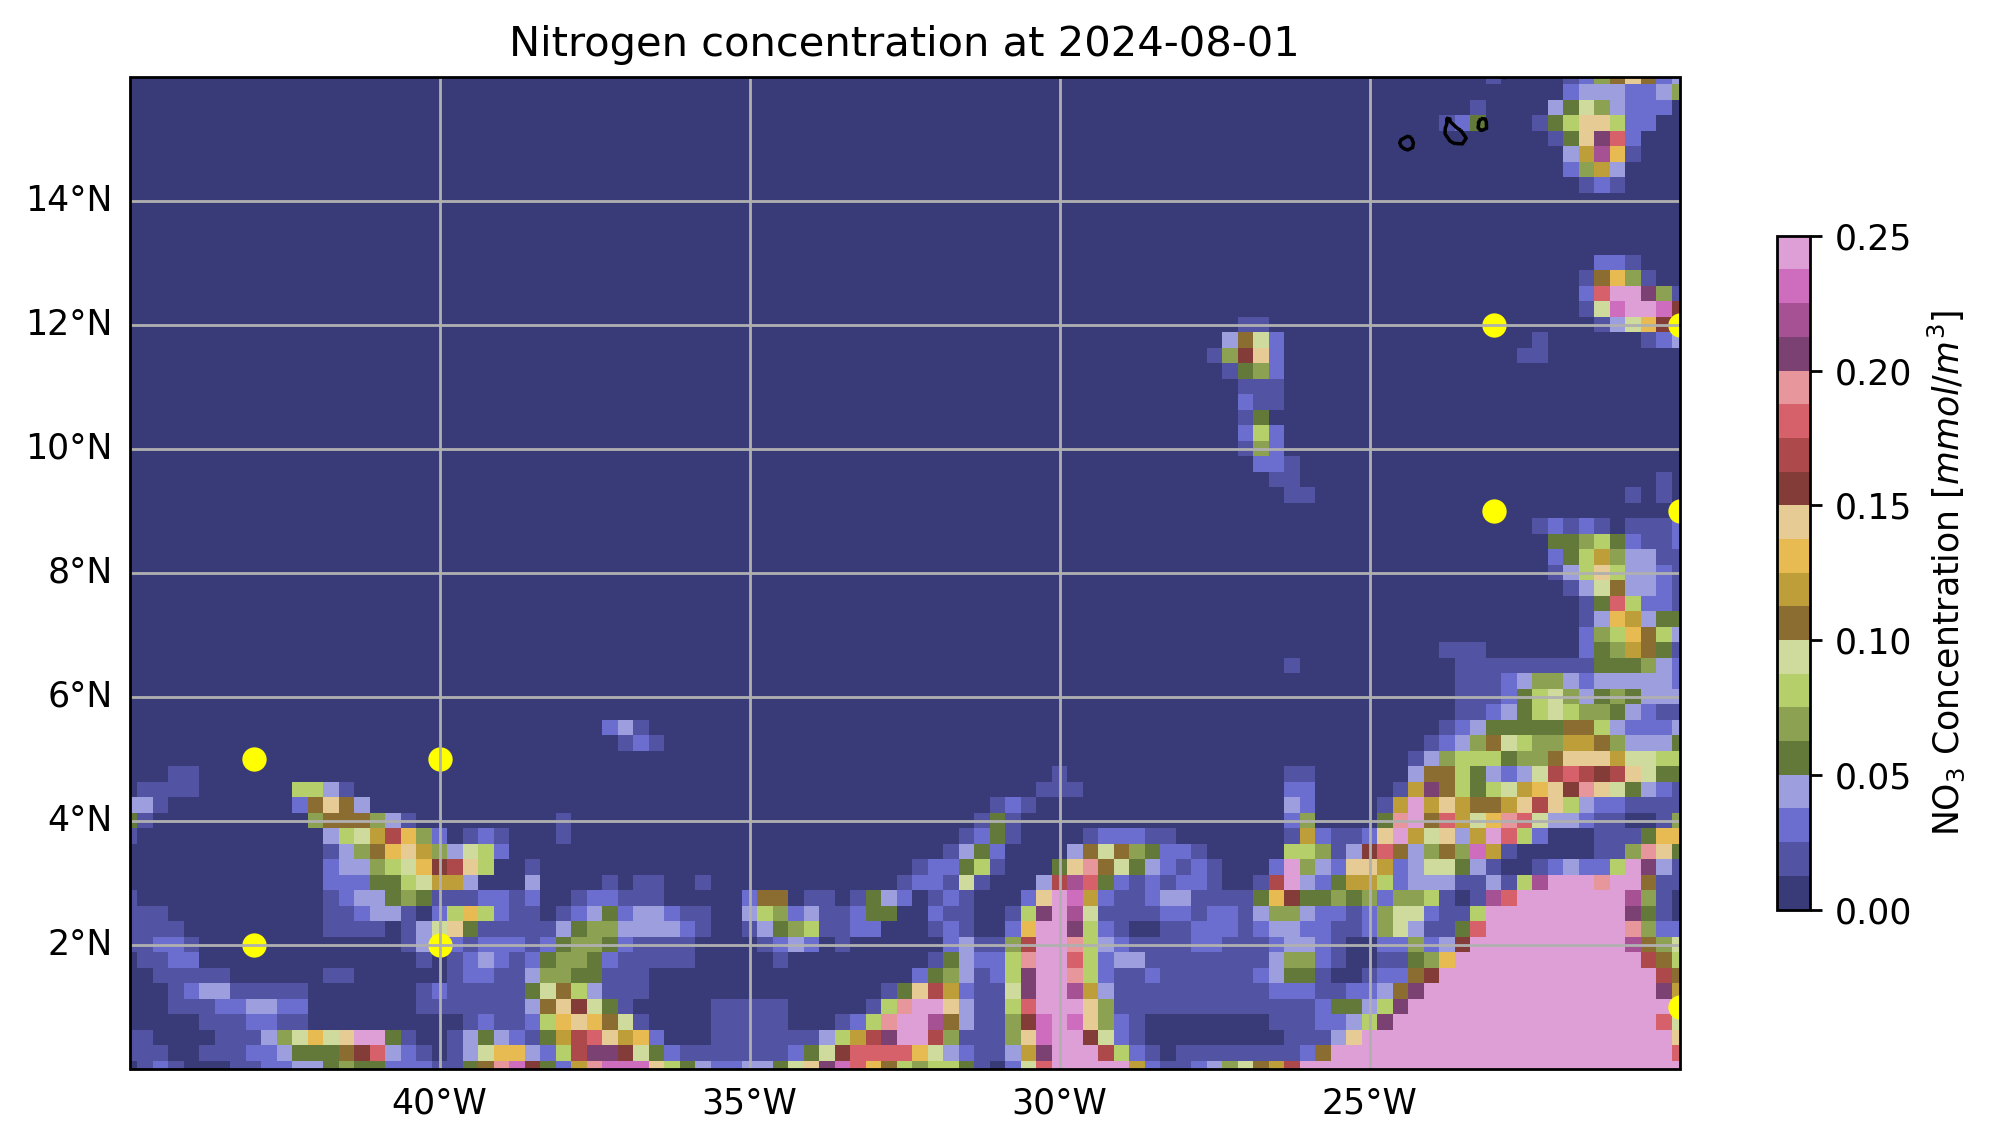

In [31]:
#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.no3.lon, fieldset.no3.lat, fieldset.no3.data[0,0,:,:], vmax = 0.25, cmap='tab20b',
             transform=ccrs.PlateCarree())
pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Nitrogen concentration at {starttime.date()}')
ax.set_extent([-45,-20,0,16])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label(f'NO$_3$ Concentration [$mmol/m^3$]')
plt.show()

/tmp/ipykernel_494822/3700511334.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')


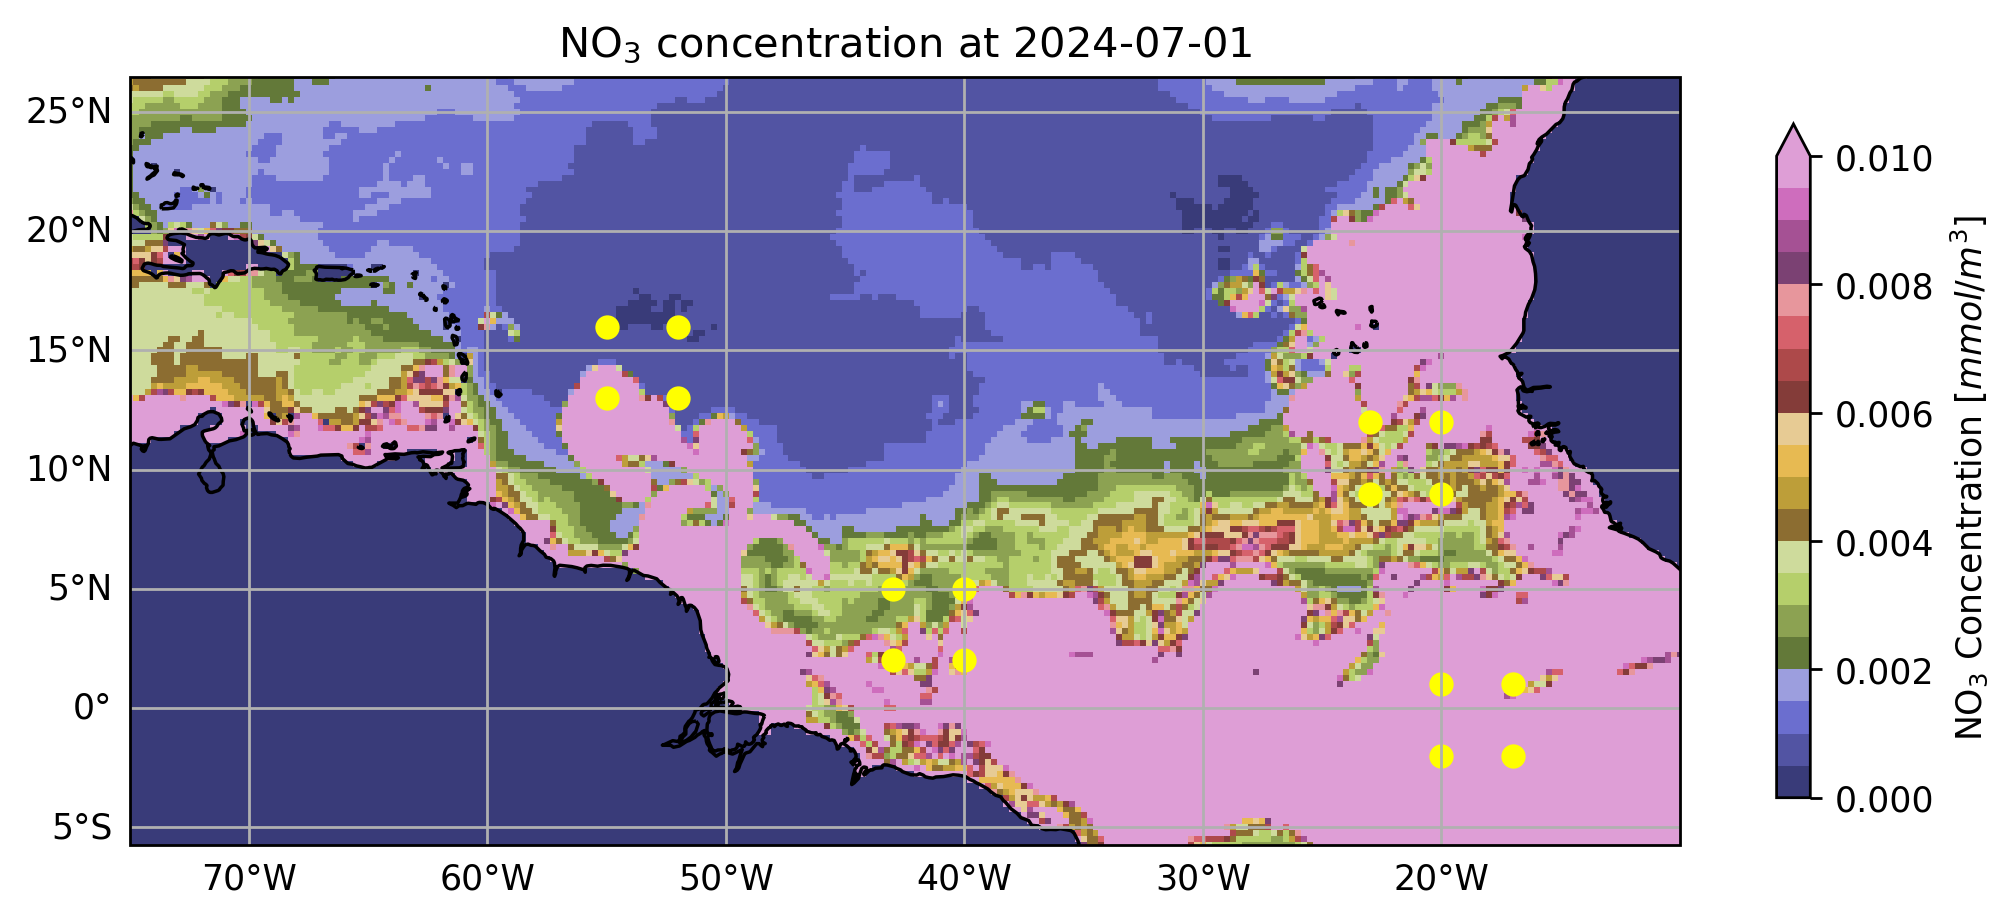

In [16]:
#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.no3.lon, fieldset.no3.lat, fieldset.no3.data[0,0,:,:], vmax = 0.01, cmap='tab20b',
             transform=ccrs.PlateCarree())
pplot = ax.plot(pset.lon, pset.lat, "ko", color='yellow')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'NO$_3$ concentration at {starttime.date()}')
ax.set_extent([-75,-10,-5,23])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5, extend = 'max')
cbar.set_label(f'NO$_3$ Concentration [$mmol/m^3$]')
plt.show()

In [4]:
# #Defining particle set that we can advect on fieldset
nparticles = 16   #how many particles will be advected

class SargassumParticle(parcels.JITParticle):
    temperature =   parcels.Variable('temperature', dtype=np.float32, to_write=True, initial=0)
    salinity =      parcels.Variable('salinity', dtype=np.float32, to_write=True, initial=0)
    weight_SF3 =    parcels.Variable('weight_SF3', dtype=np.float32, to_write=True, initial=50)
    weight_SN1 =    parcels.Variable('weight_SN1', dtype=np.float32, to_write=True, initial=50)
    weight_SN8 =    parcels.Variable('weight_SN8', dtype=np.float32, to_write=True, initial=50)
    nitrogen =      parcels.Variable('nitrogen', dtype=np.float32, to_write=True, initial=0)

pset = parcels.ParticleSet.from_list(
      fieldset=fieldset,  # the fields on which the particles are advected
      pclass = SargassumParticle,
      lon=[-43, -43, -40, -40, 
           -20, -20, -17, -17,
           -55, -55, -52, -52,
           -23, -23, -20, -20], # a vector of release longitudes
      
      lat=[2,  5,  2, 5,
           -2, 1, -2, 1,
           13, 16, 13, 16,
           9, 12, 9, 12],       # a vector of release latitudes

      depth=[0] * nparticles    # a vector of release depths
  )

# pset = parcels.ParticleSet.from_list(
#      fieldset=fieldset,  # the fields on which the particles are advected
#      #pclass=parcels.JITParticle.add_variables(sampling_variables),  # the type of particles (JITParticle or ScipyParticle)
#      pclass = SargassumParticle,
#      lon=[-40, -40, -40, -40, -43, -43, -43, -43 , -46, -46, -46, -46, -49, - 49, -49, -49], # a vector of release longitudes
#      lat=[2,  5,  8, 11, 2, 5,  8, 11, 2, 5,  8,11, 2, 5,  8, 11],                # a vector of release latitudes
#      depth=[0] * nparticles                              # a vector of release depths
#  )

#Defining particle set that we can advect on fieldset
# nparticles = 8   #how many particles will be advected

# sampling_variables = ['temperature', 'weight']

# class SargassumParticle(parcels.JITParticle):
#     temperature = parcels.Variable('temperature', dtype=np.float32, to_write=True, initial=0)
#     weight = parcels.Variable('weight', dtype=np.float32, to_write=True, initial=50)

# pset = parcels.ParticleSet.from_list(
#      fieldset=fieldset,  # the fields on which the particles are advected
#      #pclass=parcels.JITParticle.add_variables(sampling_variables),  # the type of particles (JITParticle or ScipyParticle)
#      pclass = SargassumParticle,
#      lon=[-46, -46, -46, -46, -49, - 49, -49, -49], # a vector of release longitudes
#      lat=[ 2, 5,  8,11, 2, 5,  8, 11],                # a vector of release latitudes
#      depth=[0] * nparticles                              # a vector of release depths
#  )


In [35]:

def nitrogen_from_field(particle, fieldset, time):
    z = particle.depth
    if z <= 0.49402538:
        z = 0.49402538
    
    particle.nitrogen = fieldset.no3[time, z, particle.lat, particle.lon] 
    
import inspect
print(repr(inspect.getsource(nitrogen_from_field)))

'def nitrogen_from_field(particle, fieldset, time):\n    z = particle.depth\n    if z <= 0.49402538:\n        z = 0.49402538\n\n    particle.nitrogen = fieldset.no3[time, z, particle.lat, particle.lon] \n'


In [119]:
def growth_temp_based(particle, fieldset, time):

    #Model parameters based on Jouanno et al. (2021) in deg Celsius
    T_opt_J = 26
    Tmin_J = 10.5
    Tmax_J = 43.8
    #Growth limitation dependent on temperature, formula from Jouanno et al. (2021).
    if particle.temperature < T_opt_J:
        limitation_factor = math.exp(-0.5 * ( (particle.temperature - T_opt_J)/ (Tmin_J - particle.temperature))**2 )
    else:
        limitation_factor = math.exp(-0.5 * ( (particle.temperature - T_opt_J)/ (Tmax_J - particle.temperature))**2 )

    #Update particle weight with doubling rate converted from day-1 to s-1
    particle.weight += limitation_factor * (fieldset.RGR_SF3 / (24*60*60)) * particle.dt
  

output_file = pset.ParticleFile(
    name=  output_folder + output_file_name, # the file name
    outputdt=timedelta(hours=2),             # the time step of the outputs
    chunks = (nparticles, 50))               #per hoeveel tijdstappen je data wordt opgeslagen

#Selecting kernels with parcels.AdvectionRK4 as default
kernels = [ parcels.AdvectionRK4 ]

if add_stokes:
    if avg_stokes:
        kernels+= [ck.avg_Stokes_drift]
    else:
        kernels+= [ck.direct_Stokes_drift]
if add_wind:
    kernels+= [ck.wind_drag]
if add_T_N_calc:
    kernels+= [ck.temperature_from_field,  ck.growth_temp_based ]

#Executing
pset.execute(
    kernels,                                    # the kernels (which define how particles move)
    runtime=timedelta(days=simulation_days),    # the total length of the run
    dt=dtime_execute,                           # the timestep of the kernel
    output_file=output_file,
    )

INFO: Output files are stored in /storage/shared/oceanparcels/output_data/data_Elena/SIM_june9_withoutN.zarr.
100%|██████████| 1296000.0/1296000.0 [05:14<00:00, 4114.63it/s]


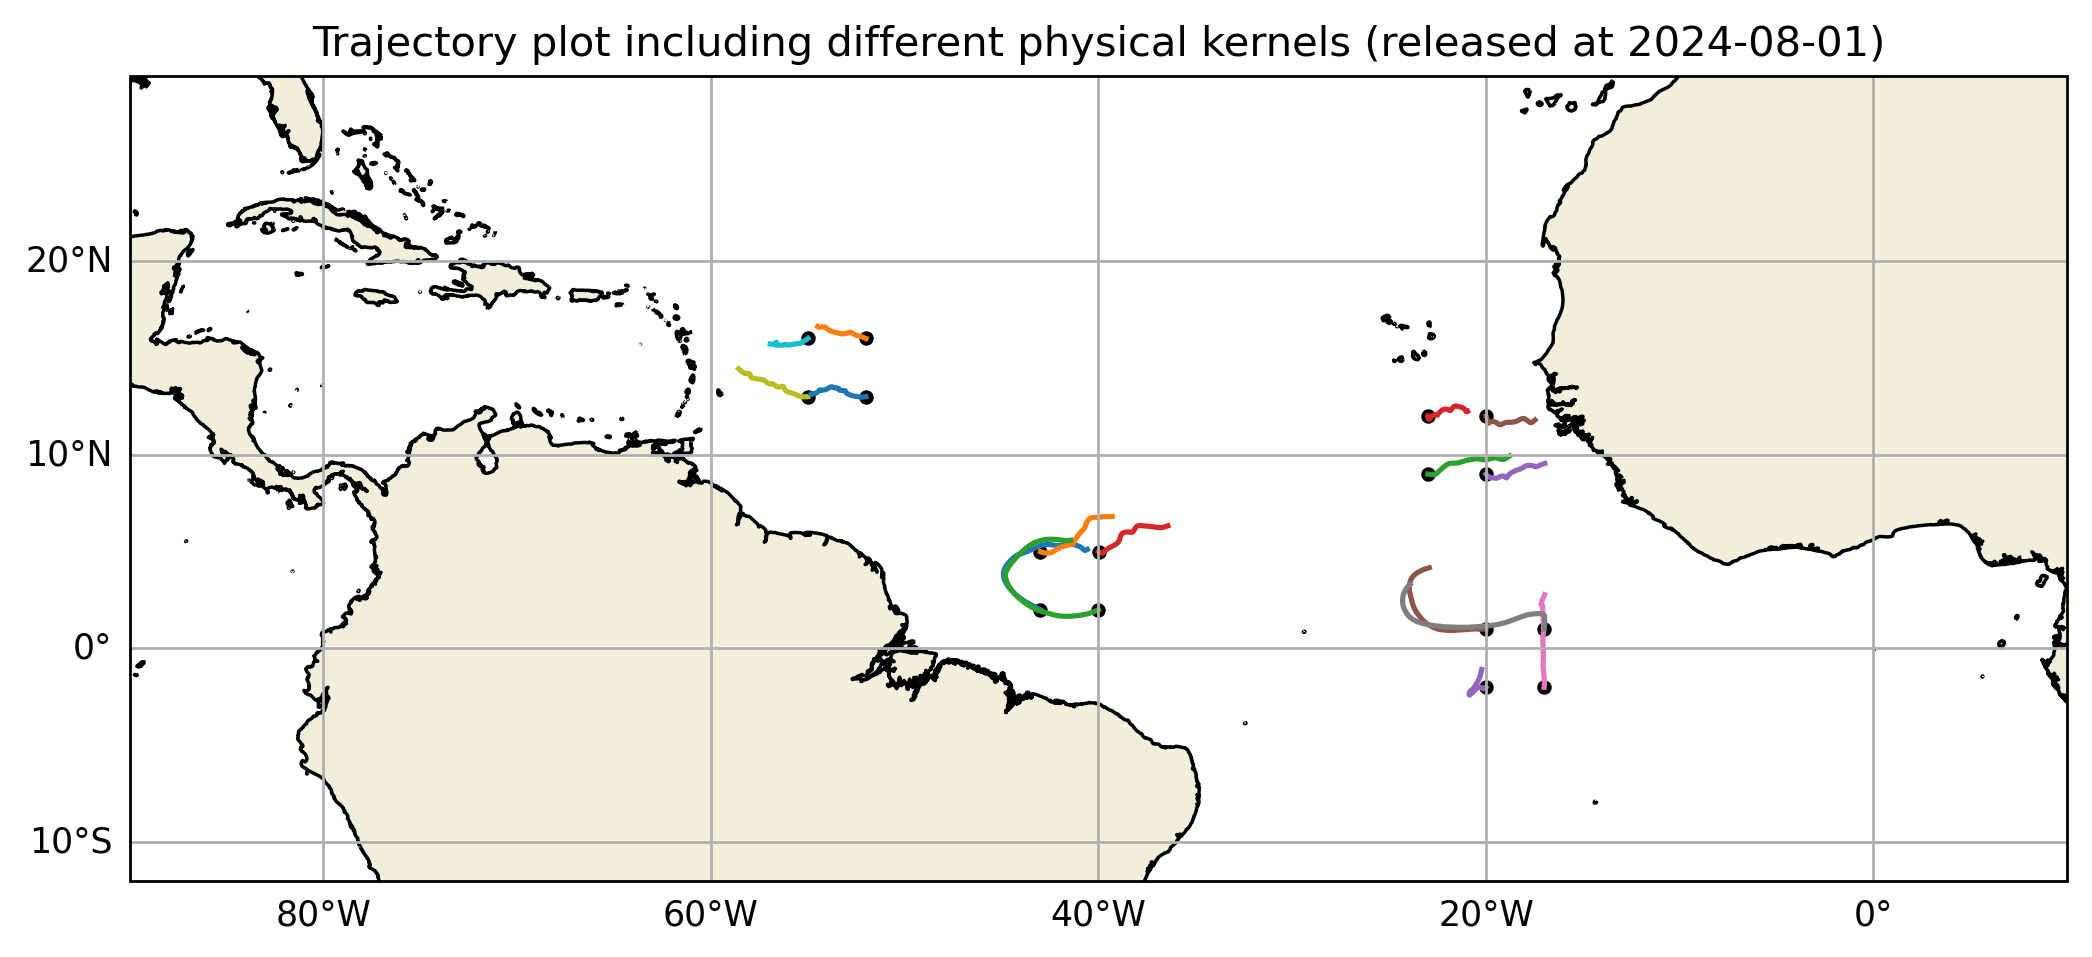

In [12]:
DSadv = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Physical_check_adv.zarr")
DSst =  xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Physical_check_adv_st.zarr")
DSwi =  xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Physical_check_adv_st_wi.zarr")

DS9 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SIM_june9.zarr")
DS9_comp = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SIM_june9_withoutN.zarr")

figcheck = plt.figure(figsize = (10,6), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
#Release locations
pplot = ax.scatter(DS9.lon[:,0], DS9.lat[:,0], s = 10 ,color='black') #Transposing lon and lat arrays!
#Trajectories
tplot = ax.plot(DS9.lon.T, DS9.lat.T, "-" ) #Transposing lon and lat arrays!
#tplot = ax.plot(DS9_comp.lon.T, DS9_comp.lat.T, "-" ) #Transposing lon and lat arrays!
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Trajectory plot including different physical kernels (released at {starttime.date()})')
ax.set_extent([-90,10,-8,20])
plt.show()

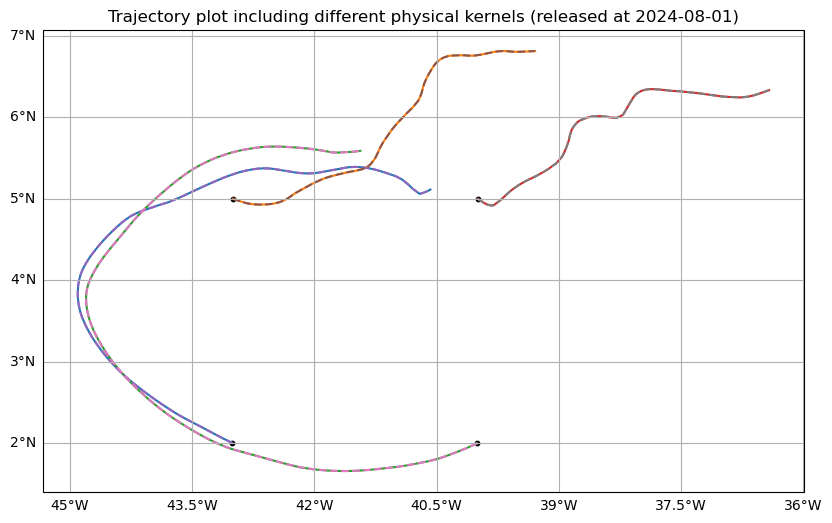

In [124]:
figcheck = plt.figure(figsize = (10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
#Release locations
pplot = ax.scatter(DS9.lon[:4,0], DS9.lat[:4,0], s = 10 ,color='black') #Transposing lon and lat arrays!
#Trajectories
tplot = ax.plot(DS9.lon[:4,:].T, DS9.lat[:4,:].T, "-" ) #Transposing lon and lat arrays!
tplot = ax.plot(DS9_comp.lon[:4,:].T, DS9_comp.lat[:4,:].T, "--" ) #Transposing lon and lat arrays!
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Trajectory plot including different physical kernels (released at {starttime.date()})')
#ax.set_extent([-90,10,-8,20])
plt.show()

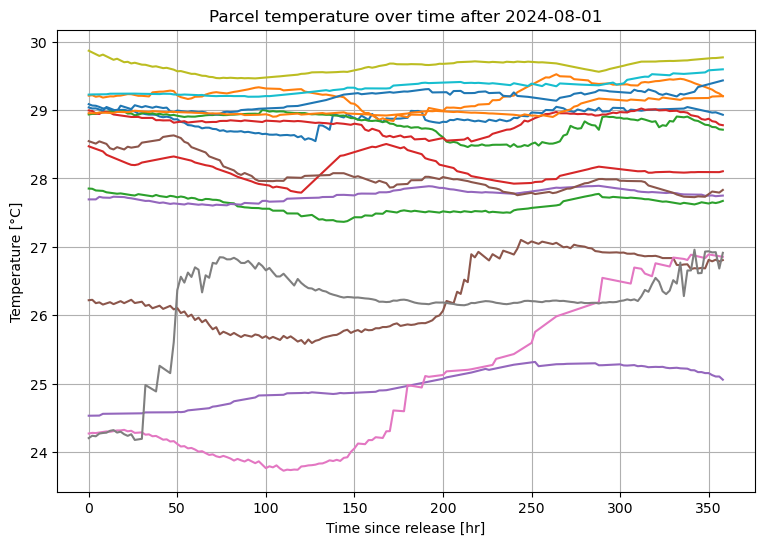

In [128]:
time_in_hours = ((DS9['time']-DS9['time'][:,0]).astype("timedelta64[h]"))

figtemp = plt.figure(figsize = (9,6))
plt.plot(time_in_hours.transpose(), DS9.temperature.transpose() )
plt.title(f'Parcel temperature over time after {starttime.date()}')
plt.xlabel('Time since release [hr]')
plt.ylabel('Temperature [°C]')
plt.grid()
plt.show()

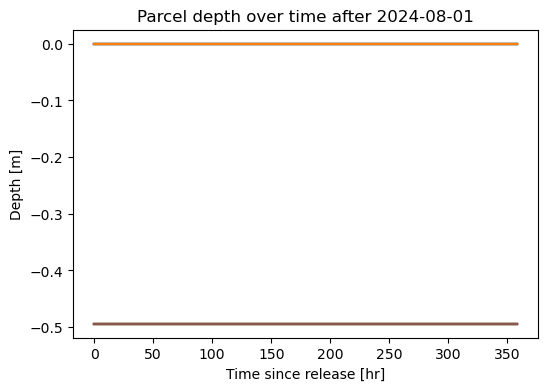

In [125]:
figz = plt.figure(figsize = (6,4))
plt.plot(time_in_hours.transpose(), -DS9.z.transpose() )
plt.plot(time_in_hours.transpose(), -DS9_comp.z.transpose() )
plt.title(f'Parcel depth over time after {starttime.date()}')
plt.xlabel('Time since release [hr]')
plt.ylabel('Depth [m]')
plt.show()

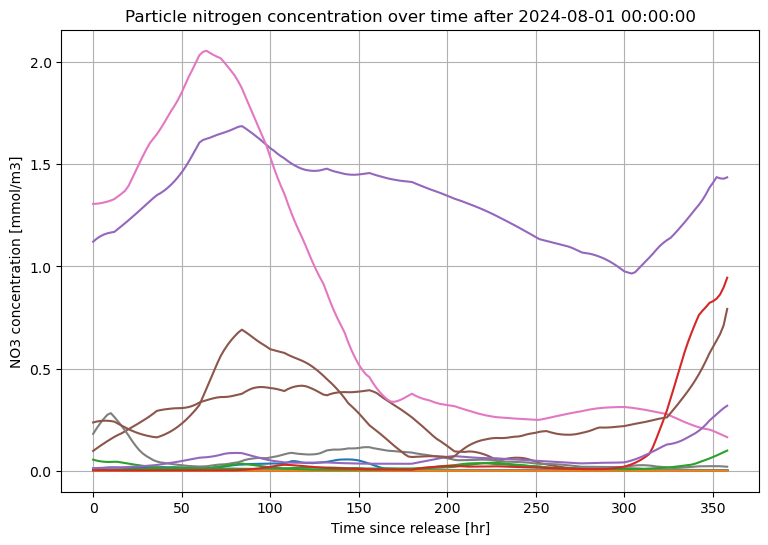

In [130]:
figN = plt.figure(figsize = (9,6))
plt.plot(time_in_hours.transpose(), DS9.nitrogen.transpose() )
plt.title(f'Particle nitrogen concentration over time after {starttime}')
plt.xlabel('Time since release [hr]')
plt.ylabel('NO3 concentration [mmol/m3]')
plt.grid()
plt.show()

In [2]:
import calculate_distance as cd
x = DSadv["lon"][:4,:].values
y = DSadv["lat"][:4,:].values

xs = DSst["lon"][:4,:].values
ys = DSst["lat"][:4,:].values

xw = DSwi["lon"][:4,:].values
yw = DSwi["lat"][:4,:].values

dxs = xs - x
dys = ys - y

dxw = xw - x
dyw = yw - y

distance = np.cumsum( np.sqrt(np.square(np.diff(x)) + np.square(np.diff(y))), axis=1)  # d = (dx^2 + dy^2)^(1/2)
rel_dist = np.cumsum( np.sqrt(np.square(np.diff(dxs)) + np.square(np.diff(dys))), axis=1)
rel_dist_w = np.cumsum( np.sqrt(np.square(np.diff(dxw)) + np.square(np.diff(dyw))), axis=1)

s = cd.cumulative_distance_01(DSadv)
s_s = cd.cumulative_distance_01(DSst)
s_w = cd.cumulative_distance_01(DSwi)

print(np.shape(x), np.shape(xs), np.shape(dxs), np.shape(rel_dist))




KeyboardInterrupt



In [3]:
figweight = plt.figure(figsize = (9,6))
plt.plot(time_in_hours.transpose(), DS9.weight_SF3.transpose() )
plt.plot(time_in_hours.transpose(), DS9.weight_SN1.transpose() )
plt.plot(time_in_hours.transpose(), DS9.weight_SN8.transpose() )
plt.title(f'Parcel weight over time (released at {starttime.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Weight [g]')
#plt.yticks([50,70,90,110,130,150,170,190])
plt.yticks([50,100,150])
plt.grid()
plt.show()

NameError: name 'time_in_hours' is not defined

<Figure size 900x600 with 0 Axes>